In [ ]:
import requests

# pip install beautifulsoup4
from bs4 import BeautifulSoup

# https://www.weather.go.kr/ > 관측기후 > 육상 > 도시별관측
response = requests.get("https://www.weather.go.kr/w/obs-climate/land/city-obs.do")
soup = BeautifulSoup(response.content, 'html.parser')

table = soup.find('table', id='weather_table')

table

<table class="table-col" id="weather_table">
<caption>도시별 기상실황표로 지점, 날씨, 기온, 강수, 바람, 기압등을 안내한 표입니다.</caption>
<colgroup>
<col span="13" style="width:calc(100% / 13)"/>
</colgroup>
<thead>
<tr class="table_header tablesorter-ignoreRow" id="table_header1">
<th scope="col">	
										지점
										
									</th>
<th colspan="4" id="headers-weather" scope="col">날씨</th>
<th colspan="3" id="headers-temp" scope="col">기온(℃)</th>
<th colspan="3" id="headers-rain" scope="col">강수</th>
<th colspan="2" id="headers-wind" scope="col">바람</th>
<th id="headers-press" scope="col">기압(hPa)</th>
</tr>
<tr class="table_header" id="table_header2">
<th scope="col">
										이름
										
									</th>
<th headers="headers-weather" scope="col">현재일기 </th>
<th headers="headers-weather" scope="col">시정<br/>km</th>
<th headers="headers-weather" scope="col">운량<br/>1/10</th>
<th headers="headers-weather" scope="col">중하운량</th>
<th headers="headers-temp" scope="col">현재<br/>기온</th>
<th headers="headers-temp" scope="co

In [6]:
trs = table.select('tbody tr')

data = []
for tr in trs:

    tds = tr.find_all('td')
    
    point = tds[0].text
    temperature = tds[5].text
    humidity = tds[10].text

    # print([point, temperature, humidity])

    data.append([point, temperature, humidity])

data

[['강릉', '9.3', '15'],
 ['강진군', '10.6', '33'],
 ['강화', '5.0', '37'],
 ['거제', '10.3', '22'],
 ['거창', '9.8', '21'],
 ['경주시', '9.8', '17'],
 ['고산', '10.8', '44'],
 ['고창', '8.8', '36'],
 ['고창군', '9.2', '36'],
 ['고흥', '12.4', '19'],
 ['광양시', '12.5', '17'],
 ['광주', '9.9', '26'],
 ['구미', '9.7', '14'],
 ['군산', '8.8', '30'],
 ['금산', '8.4', '17'],
 ['김해시', '11.1', '13'],
 ['남원', '9.3', '27'],
 ['남해', '10.2', '25'],
 ['대관령', '3.5', '14'],
 ['대구', '9.5', '15'],
 ['대전', '9.0', '15'],
 ['동두천', '6.1', '29'],
 ['동해', '8.3', '25'],
 ['목포', '8.9', '44'],
 ['문경', '8.2', '14'],
 ['밀양', '11.2', '14'],
 ['백령도', '5.5', '48'],
 ['보령', '9.9', '27'],
 ['보성군', '11.0', '19'],
 ['보은', '7.9', '22'],
 ['봉화', '6.7', '14'],
 ['부산', '11.6', '15'],
 ['부안', '9.6', '27'],
 ['부여', '9.4', '25'],
 ['북강릉', '8.8', '17'],
 ['북부산', '11.2', '16'],
 ['북창원', '10.4', '14'],
 ['북춘천', '7.0', '18'],
 ['산청', '10.7', '18'],
 ['상주', '9.6', '14'],
 ['서귀포', '16.7', '40'],
 ['서산', '6.7', '39'],
 ['서울', '6.2', '38'],
 ['서청주', '7.4', '21'],
 ['

In [7]:
# pip install pandas
import pandas as pd # 데이터 처리

df = pd.DataFrame(data, columns=["point", "temperature", "humidity"]).set_index("point")
df

,temperature,humidity
point,,
강릉,9.3,15
강진군,10.6,33
강화,5.0,37
거제,10.3,22
거창,9.8,21
...,...,...
합천,10.9,16
해남,10.4,37
홍성,7.7,35


In [8]:
with open('weather.csv', 'w', encoding='UTF8') as file:
    file.write('point, temperature, humidity\n')
    for i in data:
        file.write(f'{i[0]},{i[1]},{i[2]}\n')

In [9]:
import pandas as pd # 데이터 처리

# csv 파일을 읽어서 DataFrame 객체로 만듦. 인덱스 항목(컬럼)은 point로 설정
# df = pd.read_csv('weather.csv')
df = pd.read_csv('weather.csv', index_col='point')
df

,temperature,humidity
point,,
강릉,9.3,15
강진군,10.6,33
강화,5.0,37
거제,10.3,22
거창,9.8,21
...,...,...
합천,10.9,16
해남,10.4,37
홍성,7.7,35


In [10]:
# 특별시, 광역시만 모아서 DataFrame 객체로 만듦
# loc 속성은 label-location의 약자로 레이블을 지정해 특정 인덱스의 데이터만 가져오는데 씀
city_df = df.loc[['서울', '인천', '대전', '대구', '광주', '울산', '부산']]
city_df

,temperature,humidity
point,,
서울,6.2,38
인천,5.0,36
대전,9.0,15
대구,9.5,15
광주,9.9,26
울산,9.3,14
부산,11.6,15


In [11]:
# Windows 한글 폰트 설정해야 함!
# pip install matplotlib
from matplotlib import font_manager, rc

# AttributeError: module 'matplotlib' has no attribute 'font_manager' 에러가 발생하면 해당 코드를 주석 처리한 후 실행한 후, 주석 해제 후 다시 실행하면 됨
# .get_name() 누락 주의!!!
font_path = 'C:/Windows/Fonts/H2GTRM.TTF'
font_name = font_manager.FontProperties(fname=font_path).get_name()
rc('font', family=font_name)

pandas의 plot 메서드 사용 방식

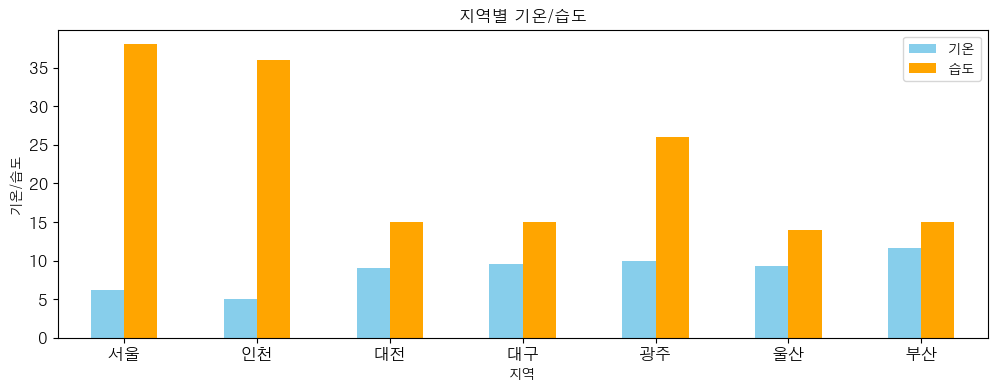

In [ ]:
import matplotlib.pyplot as plt

# 막대 그래프
city_df.plot(kind='bar', figsize=(12, 4), legend=True, fontsize=12, color=['skyblue', 'orange'])
plt.xlabel('지역')
plt.ylabel('기온/습도')
plt.title('지역별 기온/습도')
plt.legend(['기온', '습도'])
plt.xticks(rotation=0)
plt.show()


axes 객체 사용 방식

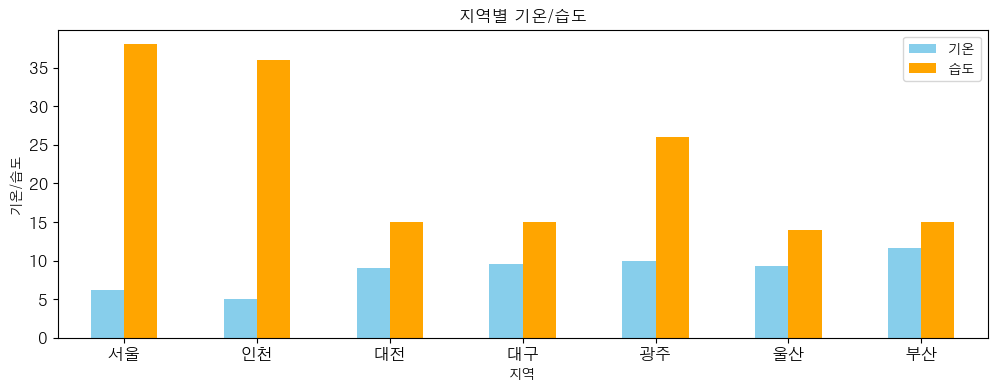

In [24]:
import matplotlib.pyplot as plt

# figure와 axes 객체 생성
fig, ax = plt.subplots(figsize=(12, 4))

# 막대 그래프 (ax 지정)
city_df.plot(kind='bar', ax=ax, legend=True, fontsize=12, color=['skyblue', 'orange'])

# axes 객체 메서드 사용
ax.set_xlabel('지역')
ax.set_ylabel('기온/습도')
ax.set_title('지역별 기온/습도')
ax.legend(['기온', '습도'])
ax.tick_params(axis='x', rotation=0)

plt.show()